# Online Shoppers — EDA & Purchase Prediction

Analyses web session data to identify what drives conversions, and trains a logistic regression classifier to predict purchases.

**Dataset:** [Online Shoppers Purchasing Intention](https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset) — place the file at `data/online_shoppers_intention.csv`

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('data/online_shoppers_intention.csv')
print(df.shape)
print(df.head())
print(f"\nConversion rate: {df['Revenue'].mean()*100:.1f}%")

(12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         

## 2. Traffic Source Analysis

In [2]:
# Conversion rate and volume per traffic type
source_revenue = df.groupby('TrafficType').agg(
    ConversionRate=('Revenue', 'mean'),
    TotalVisits=('Revenue', 'count')
).reset_index()

source_revenue['ConversionRate'] = source_revenue['ConversionRate'] * 100
source_revenue['NotConverted'] = 100 - source_revenue['ConversionRate']
source_revenue['TrafficType'] = source_revenue['TrafficType'].astype(str)
source_revenue = source_revenue.sort_values('ConversionRate', ascending=True)
source_revenue

,TrafficType,ConversionRate,TotalVisits,NotConverted
17,18,0.000000,10,100.000000
16,17,0.000000,1,100.000000
14,15,0.000000,38,100.000000
11,12,0.000000,1,100.000000
12,13,5.826558,738,94.173442
18,19,5.882353,17,94.117647
2,3,8.771930,2052,91.228070
8,9,9.523810,42,90.476190
0,1,10.689514,2451,89.310486
5,6,11.936937,444,88.063063


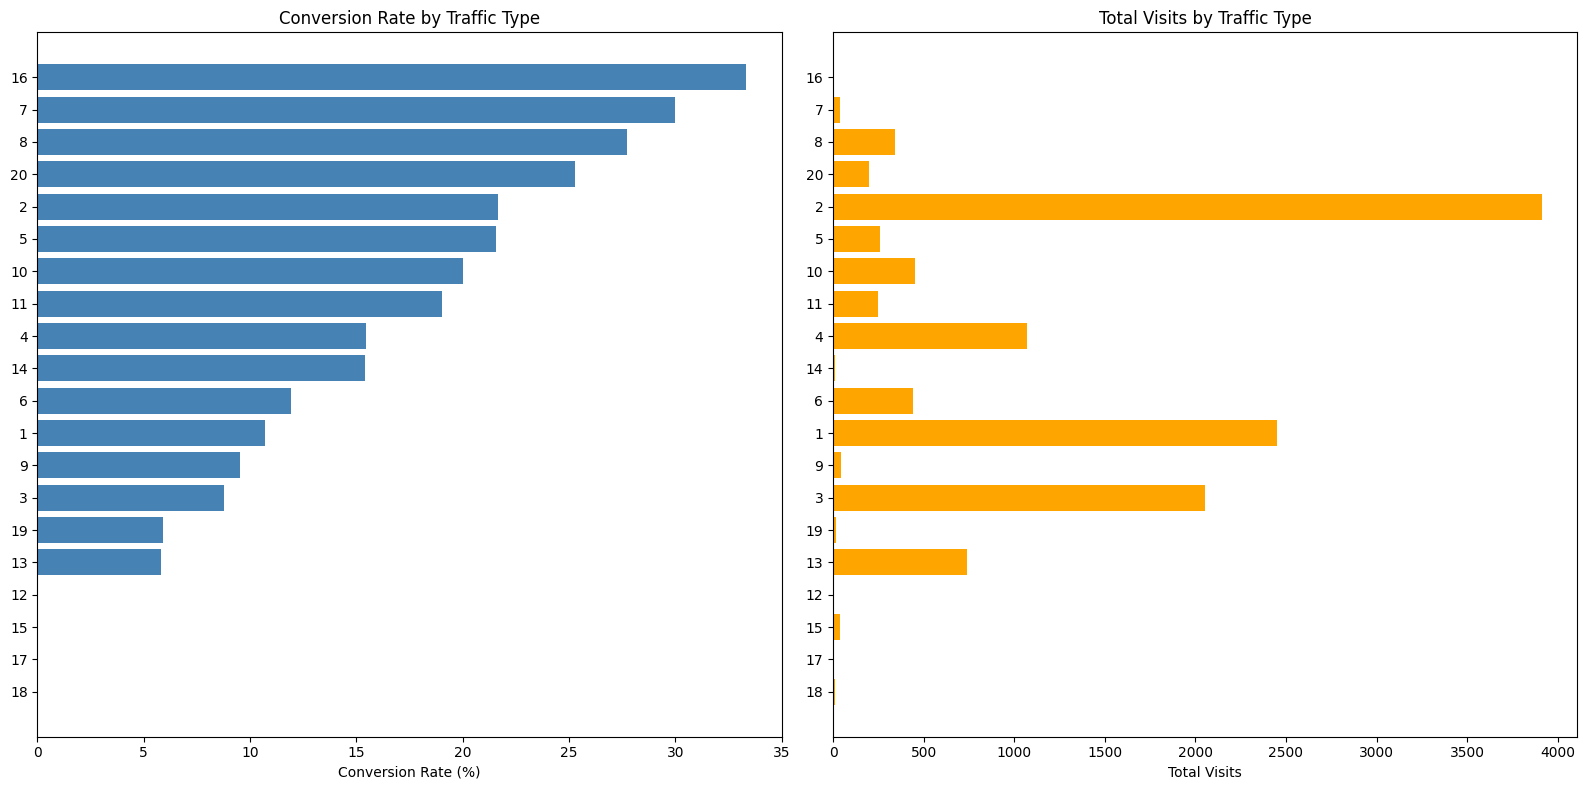

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: conversion rate per traffic type
ax1.barh(source_revenue['TrafficType'], source_revenue['ConversionRate'], color='steelblue')
ax1.set_yticks(range(len(source_revenue)))
ax1.set_yticklabels(source_revenue['TrafficType'])
ax1.set_xlabel('Conversion Rate (%)')
ax1.set_title('Conversion Rate by Traffic Type')

# Right: total visits per traffic type
ax2.barh(source_revenue['TrafficType'], source_revenue['TotalVisits'], color='orange')
ax2.set_yticks(range(len(source_revenue)))
ax2.set_yticklabels(source_revenue['TrafficType'])
ax2.set_xlabel('Total Visits')
ax2.set_title('Total Visits by Traffic Type')

plt.tight_layout()
plt.show()

## 3. Visitor Type Analysis

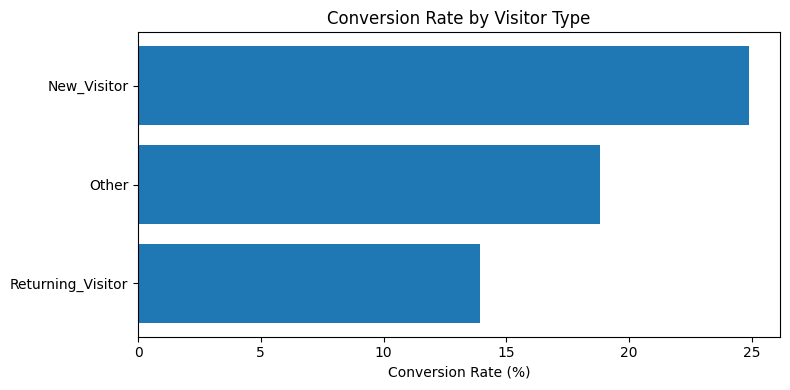

In [4]:
visitor_stats = df.groupby('VisitorType').agg(
    ConversionRate=('Revenue', 'mean'),
    TotalVisits=('Revenue', 'count')
).reset_index()

visitor_stats['ConversionRate'] = visitor_stats['ConversionRate'] * 100
visitor_stats = visitor_stats.sort_values('ConversionRate', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(visitor_stats['VisitorType'], visitor_stats['ConversionRate'])
plt.xlabel('Conversion Rate (%)')
plt.title('Conversion Rate by Visitor Type')
plt.tight_layout()
plt.show()

## 4. Bounce Rate by Month

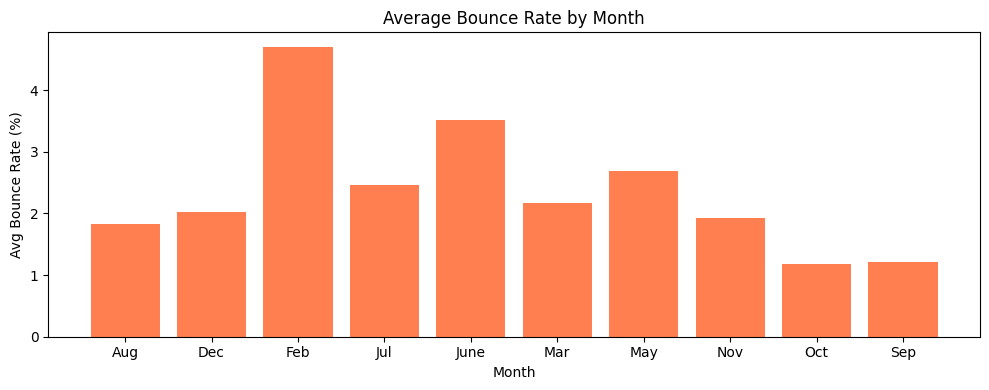

In [5]:
bounce_rate = df.groupby('Month').agg({'BounceRates': 'mean'}).reset_index()
bounce_rate['BounceRate_pct'] = bounce_rate['BounceRates'] * 100

plt.figure(figsize=(10, 4))
plt.bar(bounce_rate['Month'], bounce_rate['BounceRate_pct'], color='coral')
plt.xlabel('Month')
plt.ylabel('Avg Bounce Rate (%)')
plt.title('Average Bounce Rate by Month')
plt.tight_layout()
plt.show()

## 5. Conversion Funnel

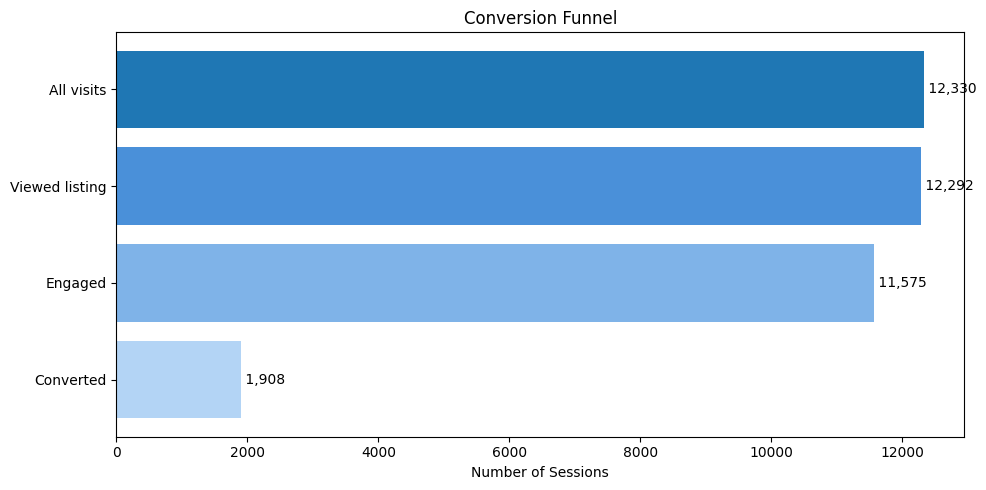

In [6]:
step1 = len(df)
step2 = len(df[df['ProductRelated'] > 0])
step3 = len(df[df['ProductRelated_Duration'] > 0])
step4 = len(df[df['Revenue'] == True])

steps = [step1, step2, step3, step4]
labels = ['All visits', 'Viewed listing', 'Engaged', 'Converted']

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, steps, color=['#1f77b4', '#4a90d9', '#7fb3e8', '#b3d4f5'])
for i, v in enumerate(steps):
    plt.text(v, i, f' {v:,}', va='center')
plt.gca().invert_yaxis()
plt.xlabel('Number of Sessions')
plt.title('Conversion Funnel')
plt.tight_layout()
plt.show()

## 6. Feature Correlation with Revenue

In [7]:
df_numeric = df.select_dtypes(include=['int64', 'float64', 'bool'])
correlation = df_numeric.corr()['Revenue'].sort_values(ascending=False)
print(correlation)

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64


## 7. Purchase Prediction — Logistic Regression

In [8]:
# Encode categorical columns
le = LabelEncoder()
df['Month_encoded'] = le.fit_transform(df['Month'])
df['VisitorType_encoded'] = le.fit_transform(df['VisitorType'])

features = ['PageValues', 'ProductRelated', 'ProductRelated_Duration',
            'Administrative', 'BounceRates', 'ExitRates',
            'Informational', 'Administrative_Duration',
            'SpecialDay', 'Month_encoded', 'VisitorType_encoded']

X = df[features]
y = df['Revenue']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' compensates for fewer purchase sessions
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.867
              precision    recall  f1-score   support

       False       0.94      0.89      0.92      2055
        True       0.58      0.74      0.65       411

    accuracy                           0.87      2466
   macro avg       0.76      0.82      0.78      2466
weighted avg       0.88      0.87      0.87      2466



/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_los